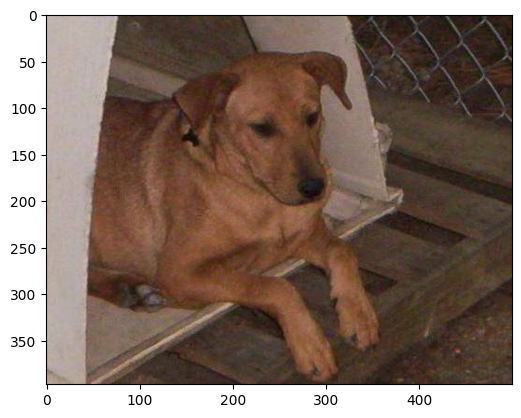

In [24]:
#dogcat 폴더에 test 200장, train 2000장을 사용했다.
from matplotlib import pyplot
from matplotlib.image import imread
image = imread('/dogcat/test/dog/dog.100.jpg')
pyplot.imshow(image)
pyplot.show()

In [17]:
from tensorflow.keras import models, layers
train_dir = '/dogcat/train'
test_dir = '/dogcat/test'

model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Flatten())
model.add(layers.Dense(units=512, activation='relu'))
model.add(layers.Dense(units=1, activation='sigmoid'))

model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale = 1./255,
                                   shear_range = 0.2,
                                   zoom_range = 0.2,
                                   horizontal_flip = True)

In [19]:
test_datagen = ImageDataGenerator(rescale = 1./255)

In [25]:
#colab에서 자동생성되는 폴더 때문에
#테스트, 훈련 데이터 제너레이션 결과가 3 class가 되는 이슈가 있었다.
!rm -rf /dogcat/.ipynb_checkpoints
!rm -rf /dogcat/test/.ipynb_checkpoints
!rm -rf /dogcat/train/.ipynb_checkpoints

In [21]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size = (128, 128),
    batch_size = 20,
    class_mode = 'binary')
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(128, 128),
    batch_size=20,
    class_mode='binary'
)

Found 2000 images belonging to 2 classes.
Found 200 images belonging to 2 classes.


In [22]:
history = model.fit(
    train_generator,
    steps_per_epoch=100,
    epochs=10,
    validation_data=test_generator,
    validation_steps=5
)

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 106s 1s/step - accuracy: 0.5520 - loss: 0.8791 - val_accuracy: 0.6000 - val_loss: 0.6553
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.6545 - loss: 0.6390 - val_accuracy: 0.6000 - val_loss: 0.6459
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.6800 - loss: 0.6057 - val_accuracy: 0.6100 - val_loss: 0.6729
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 104s 1s/step - accuracy: 0.7095 - loss: 0.5632 - val_accuracy: 0.6400 - val_loss: 0.6003
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.7205 - loss: 0.5444 - val_accuracy: 0.7700 - val_loss: 0.4903
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.7670 - loss: 0.5024 - val_accuracy: 0.7400 - val_loss: 0.5596
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.7660 - loss: 0.4899 - val_accuracy: 0.6800 - val_loss: 0.5991
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 163s 1s/step - accuracy: 0.7930 - loss: 0.4606 - val_accu

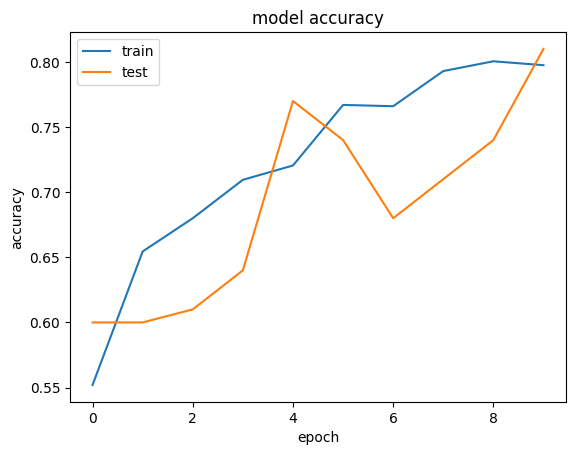

In [23]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()